Hilfsfunktionen geladen.
   Temperaturkorrektur: -0.35°C (Ø CH4 → 25°C)
✓ Dick: 2462 Zeilen, Kanäle: ['CH1', 'CH2', 'CH3']
   Temperaturkorrektur: +2.11°C (Ø CH4 → 25°C)
✓ Dünn: 6136 Zeilen, Kanäle: ['CH1', 'CH2', 'CH3']
   Temperaturkorrektur: -0.25°C (Ø CH4 → 25°C)
✓ Mittel: 2437 Zeilen, Kanäle: ['CH1', 'CH2', 'CH3']
   Temperaturkorrektur: +0.27°C (Ø CH4 → 25°C)
✓ Verguss: 2437 Zeilen, Kanäle: ['CH1', 'CH2', 'CH3']

4 Datensatz/Datensätze geladen.


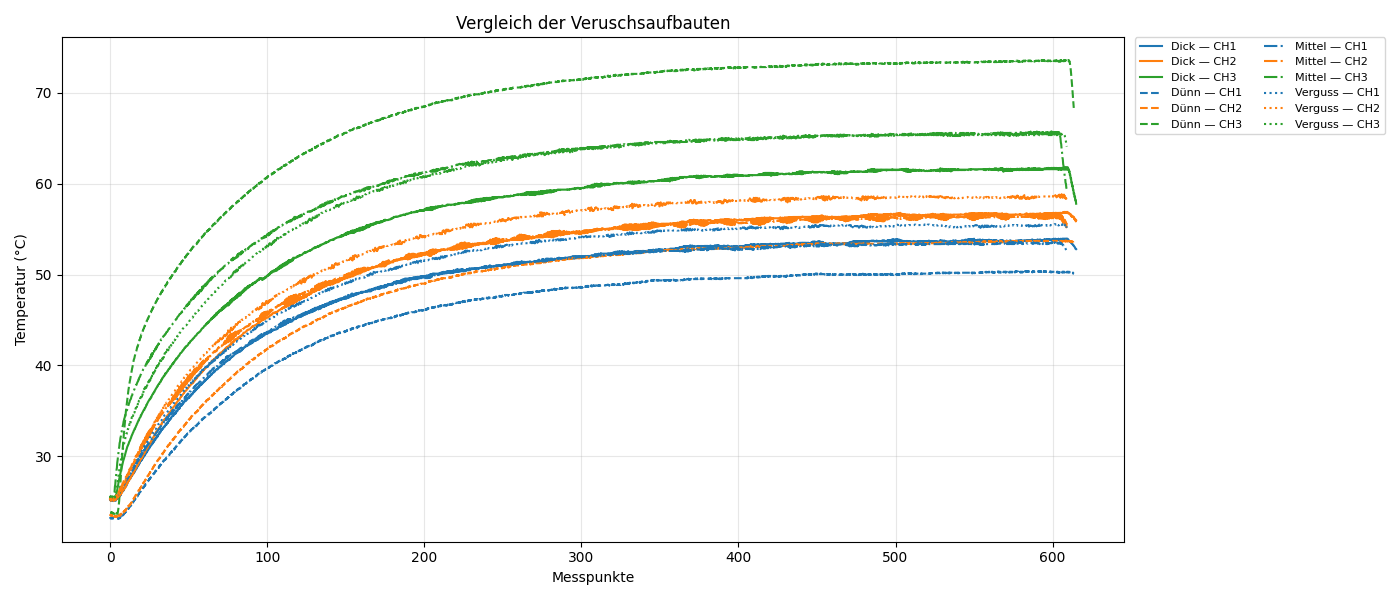

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import glob
from pathlib import Path
import ipympl
%matplotlib widget

# ──────────────────────────────────────────────
# Konfiguration — hier anpassen
# ──────────────────────────────────────────────

CSV_PATTERN   = 'data/final/*.CSV'
NTC_CHANNELS  = ['CH18', 'CH19', 'CH20']
HIDE_CHANNELS = ['CH4', 'CH15', 'CH16', 'CH17', 'CH18', 'CH19', 'CH20']  # Kanäle, die nicht geplottet werden (z.B. interne Referenz)

V_SUPPLY = 3.3
R_FIX    = 20_000
R0       = 47_000
B_CONST  = 4050
T0_K     = 298.15

SKIPROWS = 33

# Umgebungstemperatur-Kanal (nur intern, wird nicht geplottet)
TEMP_REF_CHANNEL = 'CH4'
TEMP_REF_TARGET  = 25.0   # Zieltemperatur in °C

# Gleitender Mittelwert — Fenstergröße (Anzahl Messpunkte)
FILTER_WINDOW    = 5
# Maximale Abweichung vom gleitenden Mittelwert — Ausreißer behalten Originalwert
FILTER_THRESHOLD = 1.8    # °C

# ──────────────────────────────────────────────
# Hilfsfunktionen
# ──────────────────────────────────────────────

def ntc_voltage_to_celsius(v_res, v_supply=V_SUPPLY, r_fix=R_FIX,
                            r0=R0, b=B_CONST, t0_k=T0_K):
    """Spannung über NTC (Spannungsteiler) → Temperatur in °C."""
    v_ntc    = v_supply - v_res
    r_ntc    = (v_ntc * r_fix) / (v_supply - v_ntc)
    t_kelvin = 1.0 / (1.0 / t0_k + np.log(r_ntc / r0) / b)
    return t_kelvin - 273.15


def apply_rolling_filter(series, window=FILTER_WINDOW, threshold=FILTER_THRESHOLD):
    """
    Gleitender Mittelwert mit Ausreißerschutz:
    Punkte die mehr als `threshold` vom lokalen Mittelwert abweichen
    behalten ihren Originalwert — alle anderen werden geglättet.
    """
    rolled    = series.rolling(window=window, center=True, min_periods=1).mean()
    deviation = (series - rolled).abs()
    result    = rolled.copy()
    outliers  = deviation > threshold
    result[outliers] = series[outliers]   # Ausreißer: Originalwert behalten
    return result


def compute_temp_correction(df):
    """
    Berechnet Δ = Ø(TEMP_REF_CHANNEL) - TEMP_REF_TARGET.
    Gibt 0.0 zurück falls Kanal fehlt oder leer ist.
    """
    if TEMP_REF_CHANNEL not in df.columns:
        return 0.0
    mean_temp = df[TEMP_REF_CHANNEL].dropna().mean()
    if np.isnan(mean_temp):
        return 0.0
    return TEMP_REF_TARGET - mean_temp


def detect_skiprows(path):
    with open(path, encoding='utf-8', errors='replace') as f:
        for i, line in enumerate(f):
            if 'Number' in line and 'Date' in line:
                return i
    return SKIPROWS


def read_graphtec_csv(path):
    skip = detect_skiprows(path)
    raw  = pd.read_csv(path, skiprows=skip, header=0,
                       sep=',', engine='python',
                       skipinitialspace=True, dtype=str,
                       on_bad_lines='skip')
    raw.columns = [c.strip() for c in raw.columns]

    if raw.iloc[0].astype(str).str.contains('deg|NO\.|ms', regex=True).any():
        raw = raw.iloc[1:].reset_index(drop=True)

    cols = raw.columns.tolist()

    dt_str = raw.iloc[:, 1].astype(str).str.strip()
    ms_str = raw.iloc[:, 2].astype(str).str.strip().str.replace(r'\s+', '', regex=True)
    ms_num = pd.to_numeric(ms_str, errors='coerce').fillna(0).astype(int)
    dt     = pd.to_datetime(dt_str, format='%Y/%m/%d %H:%M:%S', errors='coerce')
    dt     = dt + pd.to_timedelta(ms_num, unit='ms')

    # Alle CH-Spalten einlesen (inkl. TEMP_REF_CHANNEL für interne Nutzung)
    ch_cols_all = [c for c in cols if c.upper().startswith('CH')]
    ch_cols     = [c for c in ch_cols_all
                   if c not in HIDE_CHANNELS or c == TEMP_REF_CHANNEL]

    df = raw[ch_cols].copy()
    df.insert(0, 'datetime', dt)

    for c in ch_cols:
        df[c] = (df[c].astype(str)
                     .str.replace(r'[+\s]', '', regex=True)
                     .str.replace(',', '.', regex=False))
        df[c] = pd.to_numeric(df[c], errors='coerce')

    # ch_cols für Rückgabe: TEMP_REF_CHANNEL nicht plotten
    ch_cols = [c for c in ch_cols if c not in HIDE_CHANNELS]

    for ch in NTC_CHANNELS:
        if ch in df.columns:
            raw_v  = df[ch].where(lambda x: (x > 0) & (x < V_SUPPLY))
            df[ch] = ntc_voltage_to_celsius(raw_v)

    # Werte unter 20 ausblenden
    for c in ch_cols:
        df[c] = df[c].where(df[c] >= 20)

    df = df.dropna(subset=['datetime']).sort_values('datetime').reset_index(drop=True)
    df['elapsed_s'] = (df['datetime'] - df['datetime'].iloc[0]).dt.total_seconds()

    return df, ch_cols


def load_all_datasets(pattern_or_list):
    files = sorted(glob.glob(pattern_or_list)) if isinstance(pattern_or_list, str) else pattern_or_list

    if not files:
        print(f'⚠️  Keine Dateien gefunden: {pattern_or_list}')
        return []

    datasets = []
    for f in files:
        try:
            df, ch_cols = read_graphtec_csv(f)
            valid_cols  = [ch for ch in ch_cols
                           if ch in df.columns and df[ch].notna().any()]
            name     = Path(f).stem
            temp_corr = compute_temp_correction(df)
            print(f'   Temperaturkorrektur: {temp_corr:+.2f}°C (Ø CH4 → 25°C)')
            datasets.append({'name': name, 'df': df, 'ch_cols': valid_cols,
                             'temp_corr': temp_corr})
            print(f'✓ {name}: {len(df)} Zeilen, Kanäle: {valid_cols}')
        except Exception as e:
            print(f'✗ Fehler bei {f}: {e}')

    return datasets


print('Hilfsfunktionen geladen.')
datasets = load_all_datasets(CSV_PATTERN)
print(f'\n{len(datasets)} Datensatz/Datensätze geladen.')

# 20 gut unterscheidbare Farben — erste Hälfte für Datensatz 1, zweite für Datensatz 2 usw.
CHANNEL_COLORS = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#17becf', '#bcbd22', '#7f7f7f',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5',
    '#c49c94', '#f7b6d2', '#dbdb8d', '#9edae5', '#c7c7c7',
]
LINE_STYLES = ['-', '--', '-.', ':']


def build_multi_compare_ui(datasets):
    if not datasets:
        print('Keine Datensätze vorhanden.')
        return

    # ── Alle Kanäle ermitteln ──────────────────────────────────
    all_channels = sorted(
        set(ch for ds in datasets for ch in ds['ch_cols']),
        key=lambda x: int(x.replace('CH', ''))
    )

    # ── X-Achse: gemeinsame Zeitpunkte für Slider ──────────────
    all_times = sorted(set(
        round(t, 1)
        for ds in datasets
        for t in ds['df']['elapsed_s'].values
    ))
    if len(all_times) > 2000:
        step      = len(all_times) // 2000
        all_times = all_times[::step]
    all_times = sorted(set(all_times))

    # ── Widgets ────────────────────────────────────────────────

    # Kanal-Checkboxen
    ch_checks = {ch: widgets.Checkbox(
        value=True, description=ch,
        layout=widgets.Layout(width='80px')
    ) for ch in all_channels}

    # Pro Datensatz: Toggle + Δt-Slider
    ds_active  = {}
    ds_sliders = {}
    max_dur    = max(d['df']['elapsed_s'].max() for d in datasets)

    for i, ds in enumerate(datasets):
        color = CHANNEL_COLORS[i % len(CHANNEL_COLORS)]
        ds_active[ds['name']] = widgets.ToggleButton(
            value=True, description=ds['name'],
            layout=widgets.Layout(width='220px'),
            style={'button_color': color, 'font_weight': 'bold'}
        )
        ds_sliders[ds['name']] = widgets.FloatSlider(
            value=0.0, min=-max_dur, max=max_dur, step=0.1,
            description='Δt (s):',
            continuous_update=True,
            layout=widgets.Layout(width='450px'),
            style={'description_width': '60px'}
        )

    # X-Bereich
    x_slider = widgets.SelectionRangeSlider(
        options     = [(str(int(t)), t) for t in all_times],
        index       = (0, len(all_times) - 1),
        description = 'Zeitbereich',
        layout      = widgets.Layout(width='95%'),
        style       = {'description_width': '100px'}
    )
    x_min_box = widgets.FloatText(
        value=all_times[0],  description='Von (s):',
        layout=widgets.Layout(width='160px'),
        style={'description_width': '55px'}
    )
    x_max_box = widgets.FloatText(
        value=all_times[-1], description='Bis (s):',
        layout=widgets.Layout(width='160px'),
        style={'description_width': '55px'}
    )

    # Y-Achse
    y_auto = widgets.Checkbox(value=True, description='Y-Auto')
    y_min  = widgets.FloatText(value=0.0,   description='Y-Min:', layout=widgets.Layout(width='150px'))
    y_max  = widgets.FloatText(value=300.0, description='Y-Max:', layout=widgets.Layout(width='150px'))

    # Peak-Zoom (eng: ±1 Punkt, weit: ±10 Punkte)
    btn_peak_zoom = widgets.ToggleButton(
        value=False, description='🔍 Peak Zoom',
        button_style='warning',
        layout=widgets.Layout(width='130px')
    )
    btn_peak_zoom_wide = widgets.ToggleButton(
        value=False, description='🔍 Peak Wide',
        button_style='info',
        layout=widgets.Layout(width='130px')
    )

    def on_peak_zoom_change(change):
        if change['new']:
            btn_peak_zoom_wide.value = False
        redraw()

    def on_peak_zoom_wide_change(change):
        if change['new']:
            btn_peak_zoom.value = False
        redraw()

    btn_peak_zoom.observe(on_peak_zoom_change,           names='value')
    btn_peak_zoom_wide.observe(on_peak_zoom_wide_change, names='value')

    # Filter & Temperaturkorrektur
    btn_filter = widgets.ToggleButton(
        value=False, description='〰 Filter',
        button_style='', layout=widgets.Layout(width='110px')
    )
    btn_temp_corr = widgets.ToggleButton(
        value=False, description='🌡 25°C Korr.',
        button_style='', layout=widgets.Layout(width='120px')
    )

    # Peak-Ausrichtung
    btn_align_peaks = widgets.Button(
        description  = '⇌ Peaks ausrichten',
        button_style = 'success',
        layout       = widgets.Layout(width='160px')
    )

    def find_peak_time(ds):
        """Gibt elapsed_s des globalen Maximums eines Datensatzes zurück."""
        df      = ds['df']
        best_t  = None
        best_v  = -np.inf
        for ch in ds['ch_cols']:
            if ch not in df.columns:
                continue
            valid = df[ch].dropna()
            if valid.empty:
                continue
            idx = valid.idxmax()
            if valid[idx] > best_v:
                best_v = valid[idx]
                best_t = df['elapsed_s'].iloc[idx]
        return best_t

    def align_peaks(b):
        ref_t = find_peak_time(datasets[0])  # erster Datensatz = Referenz
        if ref_t is None:
            return
        for ds in datasets:
            peak_t = find_peak_time(ds)
            if peak_t is not None:
                shift = ref_t - peak_t
                sl    = ds_sliders[ds['name']]
                sl.value = max(sl.min, min(sl.max, shift))

    btn_align_peaks.on_click(align_peaks)

    # Schnellauswahl
    btn_all   = widgets.Button(description='Alle',      button_style='info',    layout=widgets.Layout(width='100px'))
    btn_ch1_3 = widgets.Button(description='Nur CH1–3', button_style='warning', layout=widgets.Layout(width='120px'))
    btn_none  = widgets.Button(description='Keine',     button_style='danger',  layout=widgets.Layout(width='100px'))

    def set_all(b):
        for cb in ch_checks.values(): cb.value = True
    def set_ch1_3(b):
        for ch, cb in ch_checks.items(): cb.value = ch in ('CH1', 'CH2', 'CH3')
    def set_none(b):
        for cb in ch_checks.values(): cb.value = False

    btn_all.on_click(set_all)
    btn_ch1_3.on_click(set_ch1_3)
    btn_none.on_click(set_none)

    # ── Layout ─────────────────────────────────────────────────
    header    = widgets.HTML('<b>Kanäle anzeigen:</b>')
    quick_row = widgets.HBox([btn_all, btn_ch1_3, btn_none],
                              layout=widgets.Layout(margin='4px 0'))
    ch_box    = widgets.HBox(list(ch_checks.values()),
                              layout=widgets.Layout(flex_wrap='wrap'))
    ds_rows    = [widgets.HBox([ds_active[ds['name']], ds_sliders[ds['name']]])
                  for ds in datasets]
    align_row  = widgets.HBox([btn_align_peaks], layout=widgets.Layout(margin='4px 0'))
    slider_row = widgets.HBox([x_slider, x_min_box, x_max_box])
    y_row      = widgets.HBox([y_auto, widgets.HTML('&nbsp;'), y_min, y_max, btn_peak_zoom, btn_peak_zoom_wide, btn_filter, btn_temp_corr])

    controls = widgets.VBox([
        header, quick_row, ch_box,
        widgets.HTML('<br><b>Datensätze — Ein/Aus & Zeitverschiebung:</b>'),
        *ds_rows,
        align_row,
        widgets.HTML('<br><b>X-Bereich:</b>'),
        slider_row,
        widgets.HTML('<br><b>Y-Achse:</b>'),
        y_row
    ])

    # ── Plot ───────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.canvas.header_visible = False

    # Kanal → feste Farbe
    ch_color_map = {ch: CHANNEL_COLORS[k % len(CHANNEL_COLORS)]
                    for k, ch in enumerate(all_channels)}

    def redraw(*args):
        ax.clear()
        has_data   = False
        active_chs = [ch for ch, cb in ch_checks.items() if cb.value]
        t_start, t_end = x_slider.value

        for i, ds in enumerate(datasets):
            if not ds_active[ds['name']].value:
                continue

            shift_s   = ds_sliders[ds['name']].value
            df        = ds['df']
            x_shifted = df['elapsed_s'] + shift_s

            # X-Bereich filtern
            mask    = (x_shifted >= t_start) & (x_shifted <= t_end)
            df_view = df[mask].copy()
            x_view  = x_shifted[mask]

            # Peak-Zoom: globales Maximum über alle aktiven Kanäle
            zoom_mode = 1 if btn_peak_zoom.value else (10 if btn_peak_zoom_wide.value else 0)
            if zoom_mode and active_chs:
                peak_x_global   = None
                peak_val_global = -np.inf

                for ch in active_chs:
                    if ch not in df.columns:
                        continue
                    valid = df.loc[df[ch].notna(), ch]
                    if valid.empty:
                        continue
                    idx = valid.idxmax()
                    val = valid[idx]
                    if val > peak_val_global:
                        peak_val_global = val
                        peak_x_global   = x_shifted.iloc[idx]

                if peak_x_global is not None:
                    all_x    = x_shifted.values
                    pos      = np.searchsorted(all_x, peak_x_global)
                    x_before = all_x[max(0, pos - zoom_mode)]
                    x_after  = all_x[min(len(all_x) - 1, pos + zoom_mode)]
                    mask     = (x_shifted >= x_before) & (x_shifted <= x_after)
                    df_view  = df[mask].copy()
                    x_view   = x_shifted[mask]

            for j, ch in enumerate(ds['ch_cols']):
                if ch not in active_chs:
                    continue
                if ch not in df_view.columns or df_view[ch].isna().all():
                    continue

                series = df_view[ch].copy()

                # Gleitender Mittelwert mit Ausreißerschutz
                if btn_filter.value:
                    series = apply_rolling_filter(series)

                # Temperaturkorrektur auf 25°C
                if btn_temp_corr.value:
                    series = series + ds.get('temp_corr', 0.0)

                ax.plot(x_view, series,
                        linestyle=LINE_STYLES[i % len(LINE_STYLES)],
                        color=ch_color_map.get(ch, '#333333'),
                        linewidth=1.5,
                        label=f'{ds["name"]} — {ch}')
                has_data = True

        ax.set_xlabel('Messpunkte')
        ax.set_ylabel('Temperatur (°C)')
        ax.set_title('Vergleich der Veruschsaufbauten')
        ax.grid(True, alpha=0.3)

        if has_data:
            ax.legend(ncol=2, fontsize=8,
                      loc='upper left', bbox_to_anchor=(1.01, 1),
                      borderaxespad=0)
            if not y_auto.value:
                ax.set_ylim(y_min.value, y_max.value)
            else:
                ax.relim()
                ax.autoscale_view()

        fig.tight_layout()
        fig.canvas.draw_idle()

    # ── Slider ↔ Textfelder synchron ──────────────────────────
    _updating = [False]  # Flag verhindert Endlosschleife

    def on_x_slider_change(change):
        if _updating[0]:
            return
        _updating[0] = True
        x_min_box.value = change['new'][0]
        x_max_box.value = change['new'][1]
        _updating[0] = False
        redraw()

    def on_x_box_change(change):
        if _updating[0]:
            return
        _updating[0] = True
        lo   = min(all_times, key=lambda x: abs(x - x_min_box.value))
        hi   = min(all_times, key=lambda x: abs(x - x_max_box.value))
        lo_i = all_times.index(lo)
        hi_i = all_times.index(hi)
        if lo_i <= hi_i:
            x_slider.index = (lo_i, hi_i)
        _updating[0] = False
        redraw()

    # ── Observe ────────────────────────────────────────────────
    x_slider.observe(on_x_slider_change, names='value')
    x_min_box.observe(on_x_box_change,   names='value')
    x_max_box.observe(on_x_box_change,   names='value')

    for cb in ch_checks.values():
        cb.observe(redraw, names='value')
    for tog in ds_active.values():
        tog.observe(redraw, names='value')
    for sl in ds_sliders.values():
        sl.observe(redraw, names='value')

    btn_filter.observe(redraw,    names='value')
    btn_temp_corr.observe(redraw, names='value')
    y_auto.observe(redraw,        names='value')
    y_min.observe(redraw,         names='value')
    y_max.observe(redraw,         names='value')

    redraw()
    display(controls)


build_multi_compare_ui(datasets)